In [ ]:
# importing libraries
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

In [ ]:
def fun(x):
    return 3*x**2 - 4*x + 5

In [ ]:
fun(3.2)

In [ ]:
xs = np.arange(-5,5,0.25)
ys = fun(xs)
plt.plot(xs,ys)

In [ ]:
h = 0.001
x = 3.0
(fun(x+h)-fun(x))/h

## Building neural network

In [48]:
class Value:
    def __init__(self,data,_children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.prev = set(_children)
        self._backward = lambda : None
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self,other),'+')
        def _backward():
            other.grad = 1.0 * out.grad
            self.grad = 1.0 * out.grad 
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            other.grad = self.data * out.grad
            self.grad = other.data * out.grad 
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad = (1-t**2)*out.grad
        out._backward = _backward
        return out

In [ ]:
a = Value(2.0, label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b 
e.label = 'e'
d=e+c
d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
d.prev
d._op

## Creating visualiser


In [ ]:
from graphviz import Digraph

def trace(root):
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def drawdot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid+n._op,uid)
    for n1, n2 in edges: 
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    
    return dot

In [ ]:
drawdot(L)

In [ ]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0

In [ ]:
e.grad = -2.0
c.grad = -2.0

In [ ]:
a.grad = -3.0 * -2.0
b.grad = 2.0 * -2.0

In [52]:
## Creating small neural network
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n. label = 'n'
o = n. tanh(); o. label = 'o'

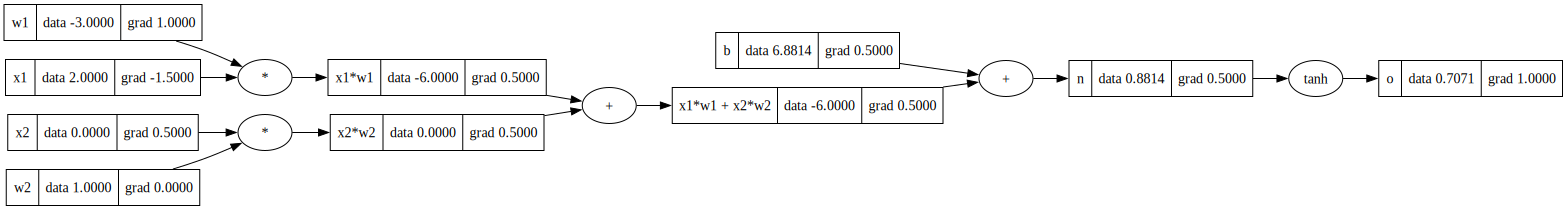

In [61]:
drawdot(o)

In [53]:
o.grad = 1.0

In [54]:
o._backward()

In [56]:
n._backward()

In [58]:
x1w1x2w2._backward()

In [60]:
x1w1._backward()
x2w2._backward()

In [ ]:
o.grad = 1.0

In [32]:
n.grad = 1-o.data**2

In [36]:
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [38]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad